In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [4]:
snapnum = 40

In [5]:
boxsize=205

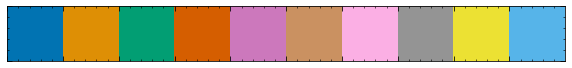

In [6]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
sns.palplot(palette_tab10)

In [7]:
color_list = palette_tab10[1:2] +  palette_tab10[2:3] +  palette_tab10[4:5] 

In [8]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG100-1'

In [9]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [10]:
h = 0.6774

In [11]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [12]:
group_sfrs = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [13]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [14]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [15]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


In [16]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [17]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [18]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [19]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [22]:
min(cent_sfrs[cent_sfrs > -5])

-3.881922612657919

In [21]:
min(group_sfrs[group_sfrs > -5])

-3.8819227

In [34]:
min(sum_sfrs[sum_sfrs > -5])

-3.804894465661307

In [37]:
min(np.log10(sat_sfrs[sat_sfrs > 0]))

-3.8048944

In [19]:
def gen_sums(sfr, bin_edges, data2bin=None):
    if data2bin is None:
        data2bin = sfr
    total = np.sum(10**sfr)
    bin_cents = (bin_edges[:-1] + bin_edges[1:]) / 2
    sums_list = np.zeros_like(bin_cents)
    for ibin, bin_left in enumerate(bin_edges[:-1]):
        mask = (data2bin > bin_left) & (data2bin < bin_edges[ibin+1])
        sums = np.sum(10**sfr[mask])
        sums_list[ibin] = sums
    return bin_cents, np.array(sums_list), total

In [21]:
bin_edges_mhalo = np.arange(9, 15.5, 0.1)
bin_cents, sums_cent, total_cent = gen_sums(cent_sfrs, bin_edges_mhalo, mvir)
bin_cents, sums_sat, total_sat = gen_sums(sum_sfrs, bin_edges_mhalo, mvir)
bin_cents, sums_group, total_group = gen_sums(group_sfrs, bin_edges_mhalo, mvir)

In [23]:
pmass = 7.6*10**7
npart = 100
mass = np.log10(pmass*npart)

Text(0.9, 0.8, '$\\mathbf{z \\sim 3}$')

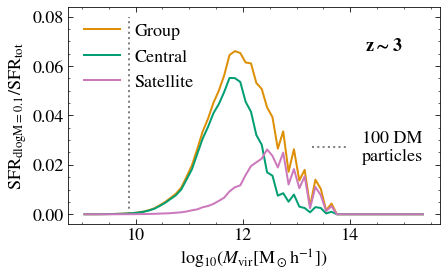

In [24]:
plt.plot(bin_cents, sums_group/total_group, label="Group", color=color_list[0])
plt.plot(bin_cents, sums_cent/total_group, label="Central", color=color_list[1])
plt.plot(bin_cents, sums_sat/total_group, label="Satellite", color=color_list[2])
ax = plt.gca()
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
leg = ax.legend(loc="upper left")
ax.add_artist(leg)
plt.ylabel("SFR$_{\mathrm{dlogM=0.1}}$/SFR$_{\mathrm{tot}}$")

vline = plt.vlines(mass, ymin=0, ymax=0.08, linestyle="dotted", color="grey", label="100 DM\nparticles")
plt.legend(handles=[vline], loc="lower right",bbox_to_anchor=(1,0.2))
ax.annotate("$\mathbf{z \sim 1.5}$", (0.9,0.8), xycoords="axes fraction", ha="right", weight="bold")
#plt.savefig("figures/contribution_continuous_z=3_100dm.pdf", format="pdf", bbox_inches="tight")

In [23]:
dir1 = "/cosma7/data/dp004/dc-zhan5/eagle-sfr/mvir/snap17"

In [24]:
ihalo_group, mvir_group, group_sfrs_eagle = np.loadtxt(f"{dir1}/group_sfrs.txt", unpack=True)

In [25]:
ihalo_cent, mvir_cent, cent_sfrs_eagle = np.loadtxt(f"{dir1}/cent_sfrs.txt", unpack=True)

In [26]:
ihalo_sat, mvir_sat, sat_sfrs_eagle = np.loadtxt(f"{dir1}/sum_sat_sfrs.txt", unpack=True)

In [29]:
min(cent_sfrs_eagle[cent_sfrs_eagle > -5])

-3.1826408

In [30]:
min(group_sfrs_eagle[group_sfrs_eagle > -5])

-3.1826408

In [31]:
min(sat_sfrs_eagle[sat_sfrs_eagle > -5])

-3.1819746

In [32]:
bin_edges_mhalo = np.arange(9, 15.5, 0.1)
bin_cents, sums_cent, total_cent = gen_sums(cent_sfrs_eagle, bin_edges_mhalo, mvir_cent)
bin_cents, sums_sat, total_sat = gen_sums(sat_sfrs_eagle, bin_edges_mhalo, mvir_sat)
bin_cents, sums_group, total_group = gen_sums(group_sfrs_eagle, bin_edges_mhalo, mvir_group)

Text(0.9, 0.8, '$\\mathbf{z \\sim 1.5}$')

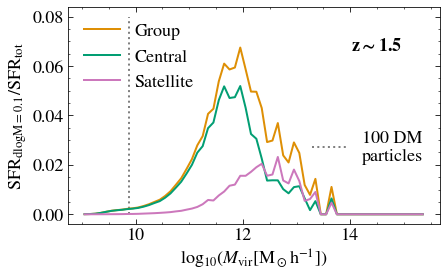

In [33]:
plt.plot(bin_cents, sums_group/total_group, label="Group", color=color_list[0])
plt.plot(bin_cents, sums_cent/total_group, label="Central", color=color_list[1])
plt.plot(bin_cents, sums_sat/total_group, label="Satellite", color=color_list[2])
ax = plt.gca()
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
leg = ax.legend(loc="upper left")
ax.add_artist(leg)
plt.ylabel("SFR$_{\mathrm{dlogM=0.1}}$/SFR$_{\mathrm{tot}}$")

vline = plt.vlines(mass, ymin=0, ymax=0.08, linestyle="dotted", color="grey", label="100 DM\nparticles")
plt.legend(handles=[vline], loc="lower right",bbox_to_anchor=(1,0.2))
ax.annotate("$\mathbf{z \sim 1.5}$", (0.9,0.8), xycoords="axes fraction", ha="right", weight="bold")
#plt.savefig("figures/contribution_continuous_z=3_100dm.pdf", format="pdf", bbox_inches="tight")